# Population Structure Analysis – Chromosome 1

This notebook performs:
- Data loading
- Filtering
- PCA
- Clustering
- Supervised classification

In [2]:
%pip install seaborn scikit-learn

  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 26.7 MB/s  0:00:00 eta 0:00:01
Using cached joblib-1.5.3-py3-none-any.whl (309 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 22.4/22.4 MB 34.1 MB/s  0:00:00 eta 0:00:01
Using cached threadpoolctl-3.6.0-py3-none-any.whl (18 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5/5 [seaborn]m3/5 [scikit-learn]
Note: you may need to restart the kernel to use updated packages.


In [3]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

In [6]:
import pandas as pd
import os

df = pd.read_csv("/Users/peppinaloumoser/Downloads/kg_matrix_chr1.csv")
sample_type = pd.read_csv("/Users/peppinaloumoser/Downloads/sample_type.csv")

df.head()

,Unnamed: 0,NA19024,HG03117,NA19120,HG03492,NA19238,NA19148,HG01956,HG00284,NA19404,...,HG02220,NA18548,NA18966,HG03123,HG02923,HG00409,HG01872,HG01805,HG02429,NA18957
0,0,23.0,23.0,23.5,23.0,24.0,23.0,23.0,24.0,23.0,...,23.0,23.0,23.5,23.0,23.0,23.0,23.0,23.0,23.5,23.5
1,1,24.5,25.0,25.0,26.0,24.5,25.0,25.5,25.0,25.0,...,24.0,24.0,24.5,25.5,26.0,24.0,24.0,25.0,24.0,25.5
2,2,19.0,19.0,18.0,19.0,19.0,21.0,19.0,19.0,18.0,...,20.0,19.0,19.0,20.5,18.0,18.5,20.0,19.0,19.5,19.0
3,3,20.5,23.0,23.0,22.0,23.0,20.5,23.0,20.5,23.0,...,22.0,23.0,23.0,22.0,23.0,23.0,22.0,23.0,20.5,23.0
4,4,13.0,13.0,13.0,10.5,10.5,13.0,13.0,10.5,8.0,...,10.5,8.0,8.0,13.0,10.5,8.0,13.0,10.5,10.5,10.5


In [7]:
df["Population"] = sample_type["Population"]

In [8]:
# Fehlende Werte checken
df.isnull().sum()

# Entfernen (einfach)
df = df.dropna()

In [9]:
X = df.drop(columns=["Population"])
y = df["Population"]

In [10]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [11]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

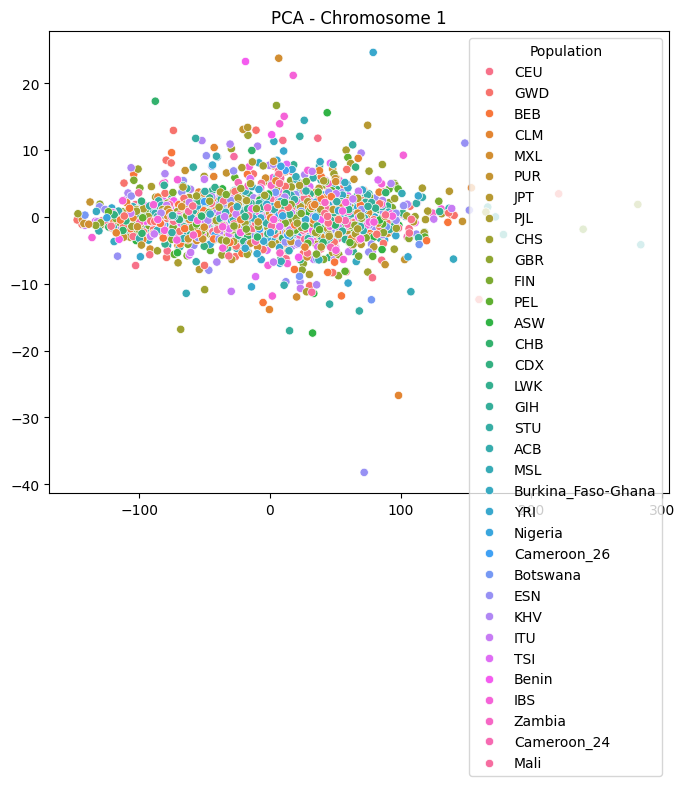

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,6))
sns.scatterplot(x=X_pca[:,0], y=X_pca[:,1], hue=y)
plt.title("PCA - Chromosome 1")
plt.show()

In [13]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(X_scaled)

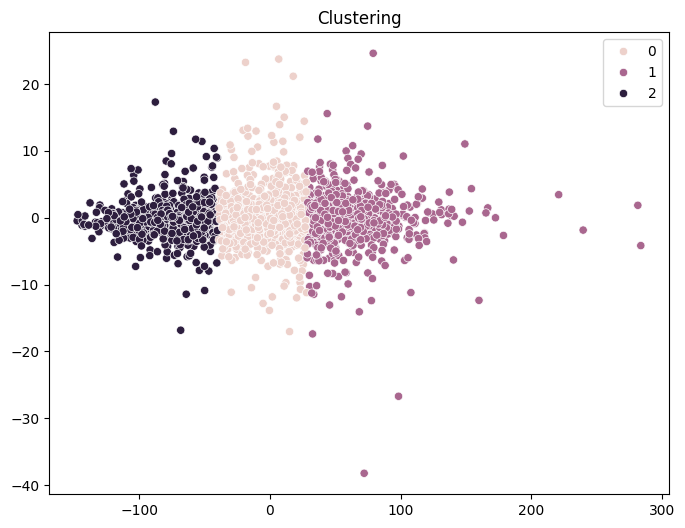

In [14]:
plt.figure(figsize=(8,6))
sns.scatterplot(x=X_pca[:,0], y=X_pca[:,1], hue=clusters)
plt.title("Clustering")
plt.show()

In [15]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

In [16]:
from sklearn.ensemble import RandomForestClassifier

clf = RandomForestClassifier()
clf.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [17]:
from sklearn.metrics import classification_report

y_pred = clf.predict(X_test)
print(classification_report(y_test, y_pred))

                    precision    recall  f1-score   support

               ACB       0.00      0.00      0.00         6
               ASW       0.00      0.00      0.00        11
               BEB       0.02      0.05      0.03        19
             Benin       0.00      0.00      0.00         7
          Botswana       0.00      0.00      0.00         5
Burkina_Faso-Ghana       0.00      0.00      0.00         6
               CDX       0.00      0.00      0.00        13
               CEU       0.08      0.11      0.10        27
               CHB       0.00      0.00      0.00        14
               CHS       0.00      0.00      0.00        27
               CLM       0.07      0.04      0.05        26
       Cameroon_24       0.00      0.00      0.00         3
       Cameroon_26       0.00      0.00      0.00         2
               ESN       0.07      0.10      0.08        21
               FIN       0.00      0.00      0.00        12
               GBR       0.00      0.00

/opt/anaconda3/envs/human_env/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/anaconda3/envs/human_env/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/anaconda3/envs/human_env/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is

The classification performance is very poor (accuracy ~4%). The model cannot reliably predict population labels from chromosome 1 STR data.